In [693]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np

In [694]:
#load the data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [695]:
#look at the data
train.head()
train.shape
#12 columns

(891, 12)

In [696]:
#lets split the data
Target = "Survived"
X = train.drop(columns=[Target])
y = train[Target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42    # reproducibility
)


In [697]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [698]:
#check for nulls
print(X_train.isnull().sum(), "\n")
#lets just drop the two Embarked missing values
X_train = X_train.dropna(subset=["Embarked"])

print(X_train.isnull().sum(), "\n")
#lets see how many ages where missing and cabin where missing line up
count = (
    X_train["Age"].isna() &
    X_train["Cabin"].isna()
).sum()

print(count)


PassengerId      0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         2
dtype: int64 

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            140
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          553
Embarked         0
dtype: int64 

126


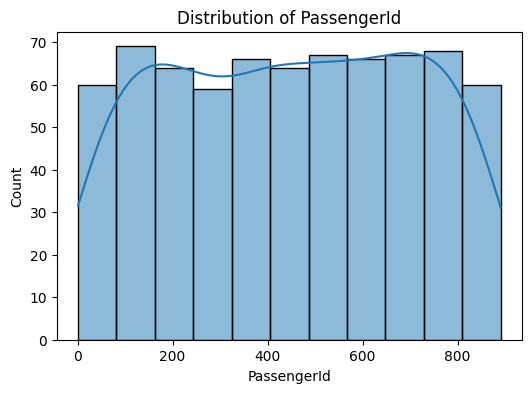

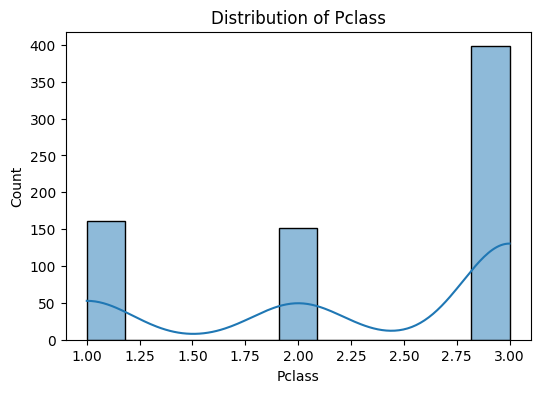

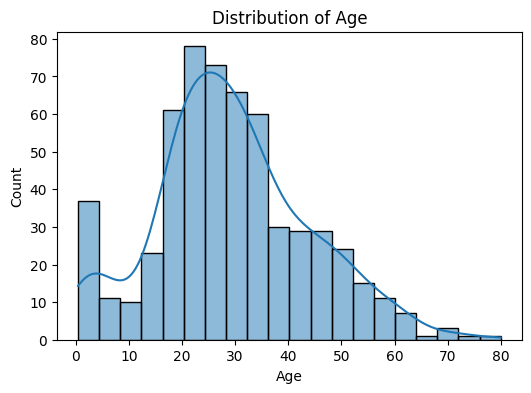

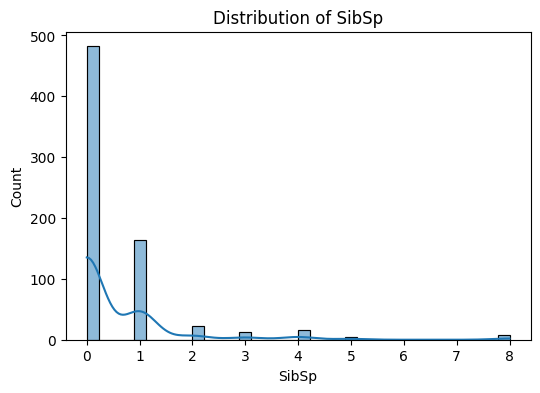

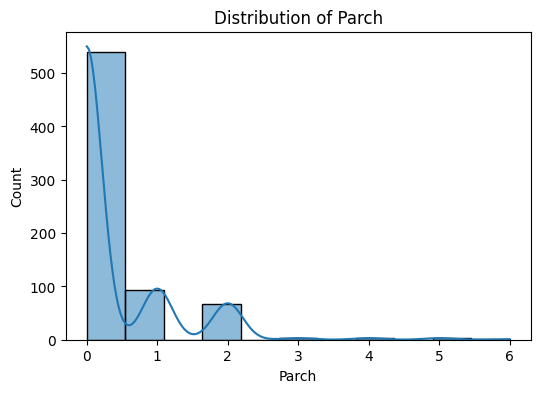

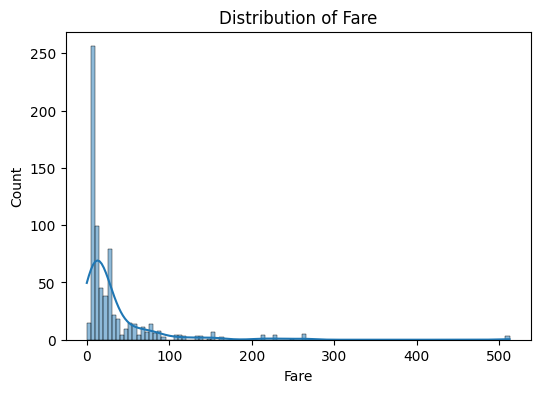

In [699]:
#lets look at the histograms to get the distributions of data
import seaborn as sns

numeric_cols = X_train.select_dtypes(include=["number"]).columns
#most of these we don't care about, but since the number of columns is small we won't specify
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#the fare class has terrible skewness to the right

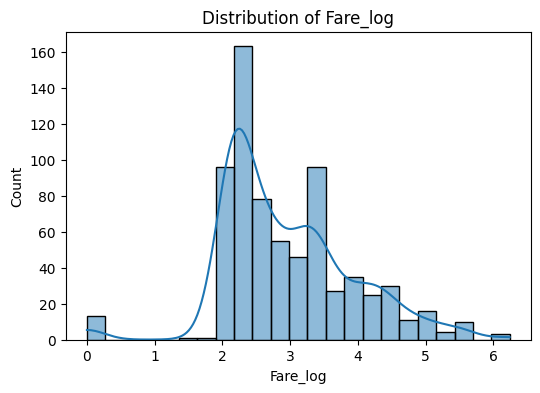

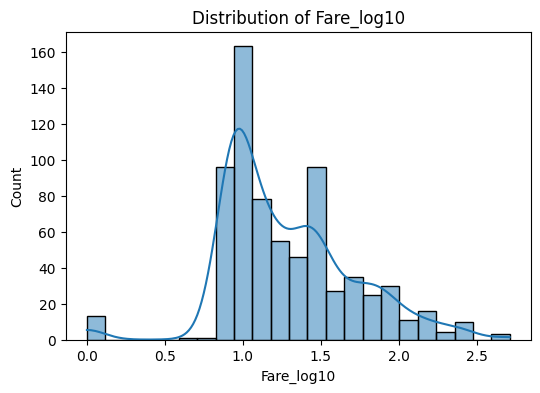

In [700]:
#lets put in a missing flag for all cols with missing values
#below is putting in missing flags for any missing values
missing_cols = X_train.columns[X_train.isna().any()]

for col in missing_cols:
    X_train[col + "_missing"] = X_train[col].isna().astype(int)
    X_test[col + "_missing"]  = X_test[col].isna().astype(int)

#lets log transform Fare column with plus 1 considering i see a fare of 0

X_train["Fare_log"] = np.log1p(X_train["Fare"])
X_test["Fare_log"]  = np.log1p(X_test["Fare"])
# that was terrible, so now we try normal log
import numpy as np

X_train["Fare_log10"] = np.log10(X_train["Fare"] + 1)
X_test["Fare_log10"]  = np.log10(X_test["Fare"] + 1)

new_cols = ["Fare_log", "Fare_log10"]
for col in new_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
#still terrible

#looks terrible considering one adult can pay for everyone


In [701]:
#now lets try and group people by Cabin
# Learn from train
cabin_counts = X_train["Cabin"].value_counts()

# Apply
X_train["CabinGroupSize"] = X_train["Cabin"].map(cabin_counts)
X_test["CabinGroupSize"]  = X_test["Cabin"].map(cabin_counts)

# Fill unseen cabins in test
X_test["CabinGroupSize"] = X_test["CabinGroupSize"].fillna(1)

X_train.isna().sum()
#above filled around 100-200 missing cabins

#based off of CabinGroupSize lets take the Fare and Divide by the GroupSize

PassengerId         0
Pclass              0
Name                0
Sex                 0
Age               140
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             553
Embarked            0
Age_missing         0
Cabin_missing       0
Fare_log            0
Fare_log10          0
CabinGroupSize    553
dtype: int64

In [702]:
X_train.head()
#I fee like Pclass along with Age, and Embarked can help with determining the cabin considering different countries are richer 
# compared to others, along with as your age increases likely so do your savings, and Pclass will determine how much money you make, 
# but their is a nuance, does the Pclass go by country standards or by one universal standard

X_train['Cabin'].unique()
#lets split it goes based off of one letter then numbers
# Extract first letter (Deck)
X_train["CabinDeck"] = X_train["Cabin"].str[0]
X_test["CabinDeck"]  = X_test["Cabin"].str[0]

# Extract numbers (Cabin Number)
X_train["CabinNum"] = X_train["Cabin"].str[1:]
X_test["CabinNum"]  = X_test["Cabin"].str[1:]

#converting numbers to numerics instead of keeping as strings
X_train["CabinNum"] = pd.to_numeric(X_train["CabinNum"], errors="coerce")
X_test["CabinNum"]  = pd.to_numeric(X_test["CabinNum"], errors="coerce")

X_train.isna().sum()

PassengerId         0
Pclass              0
Name                0
Sex                 0
Age               140
SibSp               0
Parch               0
Ticket              0
Fare                0
Cabin             553
Embarked            0
Age_missing         0
Cabin_missing       0
Fare_log            0
Fare_log10          0
CabinGroupSize    553
CabinDeck         553
CabinNum          575
dtype: int64

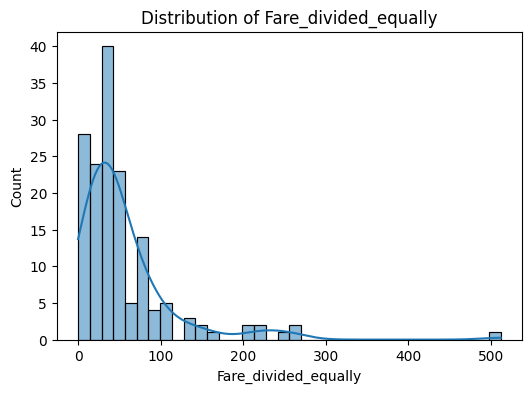

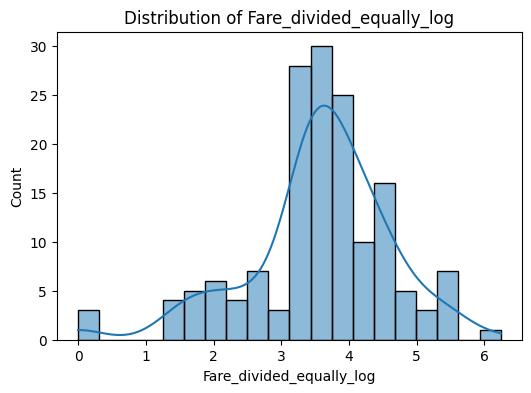

In [703]:
#based off of CabinGroupSize lets take the Fare and Divide by the GroupSize
X_train['Fare_divided_equally'] = X_train['Fare'] / X_train['CabinGroupSize']
X_test['Fare_divided_equally'] = X_test['Fare'] / X_test['CabinGroupSize']

X_train.isnull().sum()
new_cols = ["Fare_divided_equally"]
for col in new_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

#now lets log that
X_train["Fare_divided_equally_log"]  = np.log1p(X_train["Fare_divided_equally"])
X_test["Fare_divided_equally_log"]  = np.log1p(X_test["Fare_divided_equally"])

new_cols = ["Fare_divided_equally_log"]
for col in new_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(X_train[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


In [704]:
X_train.isnull().sum()

PassengerId                   0
Pclass                        0
Name                          0
Sex                           0
Age                         140
SibSp                         0
Parch                         0
Ticket                        0
Fare                          0
Cabin                       553
Embarked                      0
Age_missing                   0
Cabin_missing                 0
Fare_log                      0
Fare_log10                    0
CabinGroupSize              553
CabinDeck                   553
CabinNum                    575
Fare_divided_equally        553
Fare_divided_equally_log    553
dtype: int64

In [705]:
pd.crosstab(X_train["Pclass"], X_train["CabinDeck"]).sort_index(axis=1)
pd.crosstab(X_train["Pclass"], X_train["CabinDeck"]).sort_index(axis=1)

CabinDeck,A,B,C,D,E,F,G,T
Pclass,,,,,,,,
1,10,36,52,17,18,0,0,1
2,0,0,0,2,3,7,0,0
3,0,0,0,0,3,5,3,0


In [706]:
X_train['PassengerId'].unique()
#we are going to make the assumption since it was back in the day that people would have to wait in line for their tickets, 
# which meant a PassengerId number was assigned in order, so families which had only one payer had a number greater than zero, 
# then a bunch of zeroes, then a new person with a number greater than zero

X_train = X_train.sort_values("PassengerId")
X_train["FareGroup"] = (X_train["Fare"] > 0).cumsum()

X_test = X_test.sort_values("PassengerId")
X_test["FareGroup"] = (X_test["Fare"] > 0).cumsum()

X_train.isnull().sum()
X_train[['FareGroup']]
X_train.shape

(710, 21)

In [707]:
#we need to bin Fare_divided_equally so we can figure out who is part of the low class, medium class, and high class which Pclass attempts to do

#we need to bin eventually after we do Shapley independence plot for Age where Survived is true and false

#we need to Add cols such as girl where age is less than a certain value and sex = female, then above that is mom if sibSp > 0 where their 
# age is between 0 and 18 and age is greater than 18 and less than 50

#boy is age from 0 to 18 where sex = male

#dad is age from > 18 but < 50 and sibSp > 0 where sibSp age < 18

#male is age > 18 and no sibSp > 0  where sibSp age > 18

#women is age > 18 and no sibSp > 0 where sibSp age > 18



In [708]:
#below gets the different wealths based on fare which is divided equally
X_train["FareDiv_Bin"] = pd.qcut(
    X_train["Fare_divided_equally"],
    q=3,
    labels=["Low", "Medium", "High"]
)

# Apply same bins to test
bins = pd.qcut(
    X_train["Fare_divided_equally"],
    q=3,
    retbins=True
)[1]

X_test["FareDiv_Bin"] = pd.cut(
    X_test["Fare_divided_equally"],
    bins=bins,
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

#defining parameters
CHILD_MAX = 18
ADULT_MIN = 18
PARENT_MAX = 50

X_train["is_girl"] = (
    (X_train["Sex"] == "female") &
    (X_train["Age"] <= CHILD_MAX)
).astype(int)

X_test["is_girl"] = (
    (X_test["Sex"] == "female") &
    (X_test["Age"] <= CHILD_MAX)
).astype(int)


X_train["is_boy"] = (
    (X_train["Sex"] == "male") &
    (X_train["Age"] <= CHILD_MAX)
).astype(int)

X_test["is_boy"] = (
    (X_test["Sex"] == "male") &
    (X_test["Age"] <= CHILD_MAX)
).astype(int)


X_train["is_mom"] = (
    (X_train["Sex"] == "female") &
    (X_train["Age"].between(18, 50)) &
    ((X_train["SibSp"] > 0) | (X_train["Parch"] > 0))
).astype(int)

X_test["is_mom"] = (
    (X_test["Sex"] == "female") &
    (X_test["Age"].between(18, 50)) &
    ((X_test["SibSp"] > 0) | (X_test["Parch"] > 0))
).astype(int)


X_train["is_dad"] = (
    (X_train["Sex"] == "male") &
    (X_train["Age"].between(18, 50)) &
    ((X_train["SibSp"] > 0) | (X_train["Parch"] > 0))
).astype(int)

X_test["is_dad"] = (
    (X_test["Sex"] == "male") &
    (X_test["Age"].between(18, 50)) &
    ((X_test["SibSp"] > 0) | (X_test["Parch"] > 0))
).astype(int)

X_train["is_adult_male"] = (
    (X_train["Sex"] == "male") &
    (X_train["Age"] > 18) &
    (X_train["SibSp"] == 0) &
    (X_train["Parch"] == 0)
).astype(int)

X_test["is_adult_male"] = (
    (X_test["Sex"] == "male") &
    (X_test["Age"] > 18) &
    (X_test["SibSp"] == 0) &
    (X_test["Parch"] == 0)
).astype(int)

X_train["is_adult_female"] = (
    (X_train["Sex"] == "female") &
    (X_train["Age"] > 18) &
    (X_train["SibSp"] == 0) &
    (X_train["Parch"] == 0)
).astype(int)

X_test["is_adult_female"] = (
    (X_test["Sex"] == "female") &
    (X_test["Age"] > 18) &
    (X_test["SibSp"] == 0) &
    (X_test["Parch"] == 0)
).astype(int)



In [709]:
pd.crosstab(X_train["Pclass"], X_train["Cabin"]).sort_index(axis=1)

Cabin,A10,A14,A16,A19,A23,A24,A26,A32,A34,A36,...,E8,F E69,F G63,F G73,F2,F33,F38,F4,G6,T
Pclass,,,,,,,,,,,,,,,,,,,,,
1,1,1,1,1,1,1,1,1,1,1,...,2,0,0,0,0,0,0,0,0,1
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,3,2,0,2,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,2,0,0,1,0,3,0


In [710]:
X_train.dtypes
#one hot encode Sex, FareDiv_bin, CabinDeck, Embarked, Cabin, 

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = ['Sex', 'FareDiv_Bin', 'CabinDeck', 'Embarked', 'CabinNum']

ohe = OneHotEncoder(
    handle_unknown="ignore",   # prevents crash on new categories
    sparse_output=False        # returns pandas-friendly dense output
)

X_train_cat = ohe.fit_transform(X_train[cat_cols])

X_test_cat = ohe.transform(X_test[cat_cols])

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

#want new columns to test whether they improved our model or not and we can compare quickly to the old model
X_train = pd.concat(
    [X_train.drop(columns=cat_cols), X_train_cat],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=cat_cols), X_test_cat],
    axis=1
)

#bin ages from young, middle aged, old, older


In [711]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Age_missing',
       ...
       'CabinNum_104.0', 'CabinNum_106.0', 'CabinNum_111.0', 'CabinNum_118.0',
       'CabinNum_121.0', 'CabinNum_123.0', 'CabinNum_124.0', 'CabinNum_125.0',
       'CabinNum_128.0', 'CabinNum_nan'],
      dtype='object', length=118)

In [712]:
X_train_final.dtypes
X_train_final.dtypes
#lets do oneHotEncode for Sex, SibSp, Parch, Embarked, 

PassengerId         int64
Pclass              int64
Age               float64
SibSp               int64
Parch               int64
                   ...   
CabinNum_123.0    float64
CabinNum_124.0    float64
CabinNum_125.0    float64
CabinNum_128.0    float64
CabinNum_nan      float64
Length: 115, dtype: object

In [713]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

from sklearn.model_selection import train_test_split

#lets split the data
Target = "Survived"
X = train.drop(columns=[Target])
y = train[Target]

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,     # 20% test, 80% train
    random_state=42,    # reproducibility
    stratify = y        #this attempts to balance the data
)
X_train.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S


In [714]:
#drop ticket and name
X_train = X_train.drop(columns = ["Name", "Ticket"])
X_test = X_test.drop(columns = ["Name", "Ticket"])

In [715]:
X_train.columns

Index(['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Cabin', 'Embarked'],
      dtype='object')

In [716]:
#lets try to get the Cabin na's
X_train["Cabin"].isnull().sum()



552

In [717]:
X_train["CabinDeck"] = X_train["Cabin"].str[0]
X_test["CabinDeck"]  = X_test["Cabin"].str[0]

# Extract numbers (Cabin Number)
X_train["CabinNum"] = X_train["Cabin"].str[1:]
X_test["CabinNum"]  = X_test["Cabin"].str[1:]

#converting numbers to numerics instead of keeping as strings
X_train["CabinNum"] = pd.to_numeric(X_train["CabinNum"], errors="coerce")
X_test["CabinNum"]  = pd.to_numeric(X_test["CabinNum"], errors="coerce")

In [718]:
#lets look at the crosstab for 
pd.crosstab(X_train["Pclass"], X_train["CabinDeck"]).sort_index(axis=1)

#lets look at the fares that the 1st Pclass has
X_train.loc[X_train["Pclass"] == 1, "Fare"].describe()


count    171.000000
mean      82.999075
std       75.293715
min        0.000000
25%       30.695800
50%       57.979200
75%       99.962500
max      512.329200
Name: Fare, dtype: float64

In [719]:
#below is how to do OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

ohe = OneHotEncoder(
    handle_unknown="ignore",   # prevents crash on new categories
    sparse_output=False        # returns pandas-friendly dense output
)

X_train_cat = ohe.fit_transform(X_train[cat_cols])

X_test_cat = ohe.transform(X_test[cat_cols])

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

#want new columns to test whether they improved our model or not and we can compare quickly to the old model
X_train = pd.concat(
    [X_train.drop(columns=cat_cols), X_train_cat],
    axis=1
)

X_test = pd.concat(
    [X_test.drop(columns=cat_cols), X_test_cat],
    axis=1
)

In [720]:
#now lets do XGboost

#do XGboost model
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
xgb1 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    enable_categorical=True
)

xgb1.fit(X_train, y_train)

preds = xgb1.predict(X_test)
probs = xgb1.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, preds))
print("ROC AUC:", roc_auc_score(y_test, probs))
print(classification_report(y_test, preds))

feat_importance = pd.Series(
    xgb1.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance.head(20))


Accuracy: 0.7597765363128491
ROC AUC: 0.7959156785243742
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.64      0.67        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179

Sex_male         0.280123
Sex_female       0.150634
Cabin_nan        0.081768
CabinDeck_nan    0.063170
Pclass           0.052865
CabinDeck_B      0.046262
CabinDeck_A      0.038473
CabinNum         0.034194
Embarked_S       0.031204
CabinDeck_E      0.029538
SibSp            0.026079
Fare             0.024047
Age              0.023129
Embarked_C       0.022773
Parch            0.020812
CabinDeck_D      0.019850
CabinDeck_C      0.019412
PassengerId      0.019069
Embarked_Q       0.016597
Cabin_A32        0.000000
dtype: float32


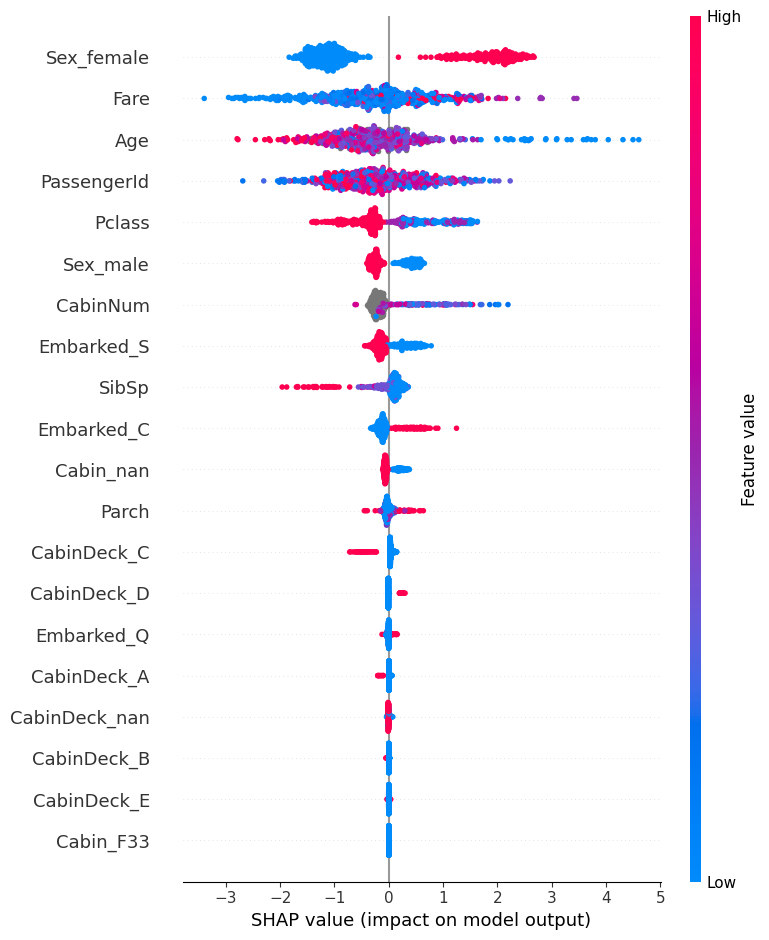

In [721]:
#shapley values for bswarm
import shap
X = 0
explainer = shap.TreeExplainer(xgb1)
#concat the trains before you do this otherwise it'll bomb out, so we do that below
X = pd.concat([X_train, X_test])

X_sample = X.sample(600, random_state=42)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)


In [722]:
#make dependence plots
shap.dependence_plot(
    "Pclass",
    shap_values,
    X_sample,
    interaction_index="Sex_Female"
)


ValueError: Could not find feature named: Sex_Female

In [ ]:
explainer = shap.TreeExplainer(xgb1)

shap_interactions = explainer.shap_interaction_values(X_sample)

shap.summary_plot(shap_interactions, X_sample)


In [ ]:
#lets deal with the Cabin na's
X_train["Cabin"].isnull().sum()